# Factor Graph Trajectory Solving From Simulated Rover Data

This notebook generates the same planar rover simulation style used in notebook 04, builds rolling MROB calibration graphs through `FactorGraphCalibration`, and compares the true simulated trajectory with the trajectory recovered from IMU and LiDAR observations.

## 1. Configuration

All tunable settings live here so the later simulated-data import block can be replaced by real data without hunting through execution cells.

In [1]:
# Trajectory controls matching notebook 04 defaults.
RECTANGLE_COUNT = 2
RECTANGLE_WIDTH = 10.0
RECTANGLE_HEIGHT = 5.0
STRAIGHT_SPEED = 1.0
TURN_DURATION = 1.5

# Sensor controls.
IMU_RATE_HZ = 100.0
LIDAR_RATE_HZ = 5.0
RANDOM_SEED = 52
FIXED_EXTRINSIC = "T_B_L"

# Initial-guess controls. Endpoints are kept exact because they are anchored.
INITIAL_POSE_ROT_STD_RAD = 0.015
INITIAL_POSE_XY_STD_M = 0.08
INITIAL_POSE_Z_STD_M = 0.0
INITIAL_POSE_RANDOM_SEED = 7
GYRO_NOISE_STD = 1e-6
ACCEL_NOISE_STD = 1e-6
LIDAR_POSE_NOISE_STD = (1e-6,)*6

# Rolling factor-graph controls.
WINDOW_SIZE = 5.0
STEP_SIZE = 1.0
IMU_SAMPLES_PER_FACTOR = 100
LIDAR_SAMPLES_PER_FACTOR = 20
FACTOR_GRAPH_METHOD = "LM"

# Output controls.
SAVE_FIGURES = True

## 2. Imports

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "calib_observability").exists():
        ROOT = candidate
        break
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

OUT = ROOT / "outputs" / "factor_graph_simulated_trajectory"
OUT.mkdir(parents=True, exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, Image, display

from calib_observability.lie_se3 import se3_exp
from calib_observability.backend import estimate_poses_dummy
from calib_observability.plotting import plot_calibration_window_chi2, plot_trajectory_comparison
from calib_observability.simulation import PlanarRoverConfig, reframe_dataset_to_fixed_extrinsic, simulate_planar_rover
from factor_graph_calibration import FactorGraphCalibration
from calib_observability.workflows import (
    build_planar_rover_dataset,
    plot_local_crlb_accuracy,
    plot_observability_over_time,
    plot_rover_dataset_overview,
    run_rolling_observability_analysis,
    save_simple_accelerometer_dashboard,
    build_dataset_from_imported_sensor_streams,
)
import transform, utils, data_processing
from tools_ahrs import plot
import mrob

In [3]:

DATASET_ROOT = Path('/mnt/d/Downloads/MobRobLab/NewCollegeDataset/01_short_experiment')
TARGET_IMU_FREQUENCY_HZ = 100.0
MAX_IMU_FILES = None

LIDAR_VOXEL_SIZE_M = 0.5
LIDAR_MAX_CORRESPONDENCE_DISTANCE_M = 1.5
LIDAR_MAX_ITERATIONS = 50
LIDAR_MAX_SCANS = None
LIDAR_SCAN_PERIOD_S = None
EXTRACT_LIDAR_IF_NEEDED = True
import new_college_dataset
from new_college_dataset import load_imus, load_lidar_relative_poses
from new_college_dataset.lidar import load_lidar_data_csv
from transform import se3_to_angvels, se3_to_velocities
import calib_observability
from calib_observability.diagnostics import DEFAULT_PRACTICAL_RANK_POLICY
from calib_observability.factor_observability import SUPPORTED_CALIBRATION_VARIABLES
from calib_observability.scaling import ParameterScales
from calib_observability.types import AccelerometerOptions, JacobianOptions

## 3. Data Import: Simulated Rover Observations

This cell is intentionally the only place that generates/imports observations. To switch to a real dataset later, replace the assignments produced here: `pose_timestamps`, `initial_poses`, `true_poses`, `imu_timestamps`, `gyrs`, `accs`, `lidar_timestamps`, `lidar_poses`, and calibration initials.

In [4]:
imu_streams = load_imus(
    DATASET_ROOT / "raw_format" / "realsense_imu",
    target_frequency_hz=TARGET_IMU_FREQUENCY_HZ,
    max_files=MAX_IMU_FILES,
)
# primary_imu_name = list(imu_streams.keys())[1]
primary_imu_name = list(imu_streams.keys())[0]
primary_imu = imu_streams[primary_imu_name]

print('Primary IMU:', primary_imu_name, primary_imu.timestamps_s.shape)

Primary IMU: realsense_imu_data (153017,)


In [5]:
STATIONARY_SAMPLES = 1000
print(np.std(primary_imu.gyro_radps[:STATIONARY_SAMPLES], axis=0))
print(np.std(primary_imu.accel_mps2[:STATIONARY_SAMPLES], axis=0))

[0.00183905 0.00178029 0.00330391]
[0.02431674 0.04163743 0.01975429]


In [6]:
lidar_data = load_lidar_data_csv(
    '~/Skoltech/phd_proposal/data/NewCollegeDataset/lidar_odometry.csv',
)

velocity_timestamps = lidar_data.scan_timestamps_s if lidar_data.scan_timestamps_s is not None else lidar_data.timestamps_s
lidar_angvel_radps = transform.relative_se3_to_angvels(lidar_data.relative_poses_se3, velocity_timestamps)
lidar_velocity_mps = transform.relative_se3_to_velocities(lidar_data.relative_poses_se3, velocity_timestamps)
print('LiDAR relative poses:', lidar_data.relative_poses_se3.shape)

LiDAR relative poses: (15300, 4, 4)


In [7]:
print(np.std(lidar_angvel_radps[:STATIONARY_SAMPLES], axis=0))
print(np.std(lidar_velocity_mps[:STATIONARY_SAMPLES], axis=0))
lidar_noise = np.hstack((np.std(lidar_angvel_radps[:STATIONARY_SAMPLES], axis=0), np.std(lidar_velocity_mps[:STATIONARY_SAMPLES], axis=0)))
print(lidar_noise)

[0.05586253 0.05452688 0.11648389]
[0.33788636 0.38617523 0.11934804]
[0.05586253 0.05452688 0.11648389 0.33788636 0.38617523 0.11934804]


In [8]:
FIXED_EXTRINSIC = 'T_B_L'
WINDOW_LENGTH = 5.0
WINDOW_STEP = 1.0
USE_SPARSE = False
NORMALIZATION = 'physical_then_column'
DISPLAY_VARIABLES = tuple(SUPPORTED_CALIBRATION_VARIABLES)
MAX_DISPLAY_ROWS = 300
MAX_DISPLAY_COLS = 40
PARAMETER_SCALES = ParameterScales()
PRACTICAL_RANK_POLICY = DEFAULT_PRACTICAL_RANK_POLICY
JACOBIAN_OPTIONS = JacobianOptions(method='analytic')
COORDINATE_NULL_FRACTION_TOLERANCE = 1e-6

# Imported-data noise/linearization assumptions. These are not measured truths;
# they define the local whitening and calibration point for observability.
IMPORTED_GYRO_NOISE_STD_RADPS = np.max(np.std(primary_imu.gyro_radps[:STATIONARY_SAMPLES], axis=0))
IMPORTED_ACCEL_NOISE_STD_MPS2 = np.max(np.std(primary_imu.accel_mps2[:STATIONARY_SAMPLES], axis=0))
IMPORTED_LIDAR_POSE_NOISE_STD = np.hstack((np.std(lidar_angvel_radps[:STATIONARY_SAMPLES], axis=0), np.std(lidar_velocity_mps[:STATIONARY_SAMPLES], axis=0)))
T_L_OUSTER_INITIAL = np.array([[-1, 0, 0, -0.006253], [0, -1, 0, 0.011775], [0, 0, 1, -0.028535], [0, 0, 0, 1]])         # lidar IMU to lidar
T_C0_OUSTER_INITIAL = np.array([[ 0.70992163, -0.70414167,  0.01399269,  0.01562753],
                                [ 0.02460003,  0.00493623, -0.99968519, -0.01981648],
                                [ 0.70385092,  0.71004236,  0.02082624, -0.07544143],
                                [ 0.,          0.,          0.,          1.        ]])
T_C0_REALSENSE_INITIAL = np.array(  [[ 0.99999395,  0.00301154,  0.00174074,  0.0058566 ],
                                    [-0.00301404,  0.99999443,  0.00143592,  0.01737982],
                                    [-0.00173641, -0.00144116,  0.99999745, -0.01595566],
                                    [ 0.,          0.,          0.,          1.        ]])
T_OUSTER_REALSENSE_INITIAL = np.linalg.inv(T_C0_OUSTER_INITIAL) @ T_C0_REALSENSE_INITIAL
T_B_I_INITIAL = T_L_OUSTER_INITIAL @ T_OUSTER_REALSENSE_INITIAL
print(T_B_I_INITIAL)
T_B_C0 = np.array([
    [ 0.,  0.,  1., 0.],
    [-1.,  0.,  0., 0.],
    [ 0., -1.,  0., 0.],
    [ 0.,  0.,  0., 1.],
])
T_B_I_INITIAL_TANGENT = mrob.SE3(T_B_I_INITIAL).Ln()
T_B_L_INITIAL_TANGENT = np.zeros(6, dtype=float)
T_B_L_INITIAL = mrob.SE3(T_B_L_INITIAL_TANGENT).T()
GYRO_BIAS_INITIAL = np.zeros(3, dtype=float)
TAU_I_INITIAL = 0.0
TAU_L_INITIAL = 0.0
INVERT_IMPORTED_LIDAR_MEASUREMENTS = False

# Timing diagnostics use an estimated LiDAR rate from scan timestamps.
if lidar_data.scan_timestamps_s is not None and len(lidar_data.scan_timestamps_s) > 1:
    LIDAR_RATE_HZ = 1.0 / float(np.median(np.diff(lidar_data.scan_timestamps_s)))
elif len(lidar_data.timestamps_s) > 1:
    LIDAR_RATE_HZ = 1.0 / float(np.median(np.diff(lidar_data.timestamps_s)))
elif LIDAR_SCAN_PERIOD_S is not None:
    LIDAR_RATE_HZ = 1.0 / float(LIDAR_SCAN_PERIOD_S)
else:
    LIDAR_RATE_HZ = 5.0
TAU_TARGET_FRAMES = 1.0
TAU_TARGET_STD_SECONDS = TAU_TARGET_FRAMES / LIDAR_RATE_HZ

SIMPLE_ACCELEROMETER_OPTIONS = AccelerometerOptions(
    mode='simple',
    factor_rate_hz=LIDAR_RATE_HZ,
    support_half_width_seconds=0.2,
    gravity_norm_tolerance_m_s2=0.75,
    low_dynamic_gyro_threshold_rad_s=0.35,
    require_low_dynamic_gate=True,
    measurement_std_m_s2=1e-6,
    save_factor_terms=True,
)
ANIMATION_MP4 = OUT / 'new_college_simple_accelerometer_dashboard.mp4'
SAVE_ANIMATION_MP4 = False
ANIMATION_MP4 = OUT / 'new_college_simple_accelerometer_dashboard.mp4'
ANIMATION_INTERVAL_MS = 300
ANIMATION_TRAJECTORY_SAMPLES = 700

print({
    'output': str(OUT),
    'window_length': WINDOW_LENGTH,
    'window_step': WINDOW_STEP,
    'lidar_rate_hz_estimate': LIDAR_RATE_HZ,
    'display_variables': DISPLAY_VARIABLES,
})


[[-0.70862101 -0.02572348 -0.70512024 -0.04210055]
 [ 0.7053852  -0.00179237 -0.7088219  -0.03752614]
 [ 0.01696954 -0.99966749  0.01941508 -0.06461745]
 [ 0.          0.          0.          1.        ]]
{'output': '/home/camel/Skoltech/phd_proposal/outputs/factor_graph_simulated_trajectory', 'window_length': 5.0, 'window_step': 1.0, 'lidar_rate_hz_estimate': 9.9996280808495, 'display_variables': ('T_B_I', 'T_B_L', 'b_g', 'tau_I', 'tau_L')}


In [9]:
def lidar_scan_timestamps_for_pipeline(lidar_data):
    if lidar_data.scan_timestamps_s is not None:
        return np.asarray(lidar_data.scan_timestamps_s, dtype=float)
    midpoint_times = np.asarray(lidar_data.timestamps_s, dtype=float)
    if midpoint_times.size == 0:
        raise ValueError('LiDAR data has no timestamps')
    if midpoint_times.size == 1:
        if LIDAR_SCAN_PERIOD_S is None:
            raise ValueError('Set LIDAR_SCAN_PERIOD_S when only one LiDAR midpoint timestamp is available')
        half_period = 0.5 * float(LIDAR_SCAN_PERIOD_S)
        return np.array([midpoint_times[0] - half_period, midpoint_times[0] + half_period], dtype=float)
    boundaries = np.empty(midpoint_times.size + 1, dtype=float)
    boundaries[1:-1] = 0.5 * (midpoint_times[:-1] + midpoint_times[1:])
    boundaries[0] = midpoint_times[0] - (boundaries[1] - midpoint_times[0])
    boundaries[-1] = midpoint_times[-1] + (midpoint_times[-1] - boundaries[-2])
    return boundaries

lidar_scan_timestamps_s = lidar_scan_timestamps_for_pipeline(lidar_data)
raw_dataset = build_dataset_from_imported_sensor_streams(
    imu_timestamps=primary_imu.timestamps_s,
    gyroscope=primary_imu.gyro_radps,
    accelerometer=primary_imu.accel_mps2,
    lidar_scan_timestamps=lidar_scan_timestamps_s,
    lidar_relative_poses=lidar_data.relative_poses_se3,
    T_B_I_initial_tangent=T_B_I_INITIAL_TANGENT,
    T_B_L_initial_tangent=T_B_L_INITIAL_TANGENT,
    gyro_bias_initial=GYRO_BIAS_INITIAL,
    tau_I_initial=TAU_I_INITIAL,
    tau_L_initial=TAU_L_INITIAL,
    gyro_noise_std=IMPORTED_GYRO_NOISE_STD_RADPS,
    accel_noise_std=IMPORTED_ACCEL_NOISE_STD_MPS2,
    lidar_pose_noise_std=IMPORTED_LIDAR_POSE_NOISE_STD,
    invert_lidar_measurements=INVERT_IMPORTED_LIDAR_MEASUREMENTS,
    true_poses_path = DATASET_ROOT / "ground_truth/registered_poses.csv",
)
dataset = reframe_dataset_to_fixed_extrinsic(raw_dataset, FIXED_EXTRINSIC)
pose_provider = estimate_poses_dummy(dataset)

print({
    'dataset_start': dataset.start_time,
    'dataset_end': dataset.end_time,
    'imu_samples': len(dataset.imu.sensor_timestamps),
    'lidar_measurements': len(dataset.lidar.measurements),
    'trajectory_mode': dataset.trajectory.mode,
})


{'dataset_start': 1583836591.182591, 'dataset_end': 1583838121.1563556, 'imu_samples': 152988, 'lidar_measurements': 15299, 'trajectory_mode': 'imported_lidar_odometry_B_equals_L'}


In [10]:
pose_timestamps = dataset.lidar.sensor_timestamps.copy()
true_poses = np.stack([dataset.trajectory.pose_at(float(t)) for t in pose_timestamps], axis=0)

imu_timestamps = dataset.imu.sensor_timestamps.copy()
gyrs = dataset.imu.gyroscope.copy()
accs = dataset.imu.accelerometer.copy()

lidar_timestamps = dataset.lidar.sensor_timestamps.copy()
lidar_poses = np.empty((lidar_timestamps.size, 4, 4), dtype=float)
lidar_poses[0] = np.eye(4)
for measurement_index, relative_pose in enumerate(dataset.lidar.measurements):
    lidar_poses[measurement_index + 1] = lidar_poses[measurement_index] @ relative_pose

# Build a slightly perturbed trajectory initial guess while preserving anchored endpoints.
rng = np.random.default_rng(INITIAL_POSE_RANDOM_SEED)
pose_perturbations = np.zeros((pose_timestamps.size, 6), dtype=float)
pose_perturbations[:, :3] = rng.normal(0.0, INITIAL_POSE_ROT_STD_RAD, size=(pose_timestamps.size, 3))
pose_perturbations[:, 3] = rng.normal(0.0, INITIAL_POSE_XY_STD_M, size=pose_timestamps.size)
pose_perturbations[:, 4] = rng.normal(0.0, INITIAL_POSE_XY_STD_M, size=pose_timestamps.size)
pose_perturbations[:, 5] = rng.normal(0.0, INITIAL_POSE_Z_STD_M, size=pose_timestamps.size)
pose_perturbations[0] = 0.0
pose_perturbations[-1] = 0.0
initial_poses = np.stack([se3_exp(xi) @ pose for xi, pose in zip(pose_perturbations, true_poses)], axis=0)

T_B_I_initial = dataset.T_B_I_true.copy()

print(f"trajectory mode: {dataset.trajectory.mode}")
print(f"fixed extrinsic: {FIXED_EXTRINSIC}, T_B_L identity: {np.allclose(dataset.T_B_L_true, np.eye(4))}")
print(f"pose nodes: {pose_timestamps.size}")
print(f"IMU samples: {imu_timestamps.size}, LiDAR odometry poses: {lidar_poses.shape[0]}")
print(f"true tau_I={dataset.tau_I_true:+.3f}s, true tau_L={dataset.tau_L_true:+.3f}s")

trajectory mode: imported_lidar_odometry_B_equals_L
fixed extrinsic: T_B_L, T_B_L identity: True
pose nodes: 15300
IMU samples: 152988, LiDAR odometry poses: 15300
true tau_I=+0.000s, true tau_L=+0.000s


In [11]:
transform.so3s_to_quats(lidar_poses[:-1, :3, :3]).shape

(15299, 4)

In [12]:
# import compare
# angvel_lidar = transform.se3_to_angvels(lidar_poses[:-1], lidar_timestamps[:-1])
# compare.    compare_smartphone_to_mocap(lidar_timestamps[1:-1], transform.so3s_to_quats(lidar_poses[:-1, :3, :3]), angvel_lidar, pose_timestamps, transform.so3s_to_quats(true_poses[:, :3, :3]), verbose=3)

In [13]:
T_B_L_WORLD = (
    T_B_C0
    @ T_C0_OUSTER_INITIAL
    @ np.linalg.inv(T_L_OUSTER_INITIAL)
)
T_B_L_WORLD

array([[-0.70385092, -0.71004236,  0.02082624, -0.07088758],
       [ 0.70992163, -0.70414167, -0.01399269, -0.0032964 ],
       [ 0.02460003,  0.00493623,  0.99968519,  0.0484382 ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [14]:
angvel_lidar = transform.se3_to_angvels(lidar_poses[:-1], lidar_timestamps[:-1])
angvel_body = transform.se3_to_angvels(true_poses[1:], pose_timestamps[1:])
R_B_L_EXPERIMENTAL = utils.scipy_rotation(angvel_lidar, angvel_body)
R_W_B_0 = np.array(true_poses[0, :3, :3])

R_W_O_0 = R_W_B_0 @ R_B_L_EXPERIMENTAL
# print(R_W_O_0)
# R_W_B_EXPERIMENTAL = utils.scipy_rotation(transform.se3_to_angvels(lidar_poses[:4000], lidar_timestamps[:4000]), transform.se3_to_angvels(true_poses[:4000], true_timestamps[:4000]))
T_W_B_EXPERIMENTAL = np.eye(4)
T_B_L_EXPERIMENTAL = np.eye(4)
T_W_B_EXPERIMENTAL[:3, :3] = R_W_O_0
T_B_L_EXPERIMENTAL[:3, :3] = R_B_L_EXPERIMENTAL
print(R_B_L_EXPERIMENTAL)
# plot(angvel_lidar[:4000])
# plot(angvel_body[:4000])
# plot(angvel_lidar - (R_B_L_EXPERIMENTAL.T @ angvel_body.T).T)
print(np.mean(np.linalg.norm(angvel_lidar - (R_B_L_EXPERIMENTAL.T @ angvel_body.T).T, axis=1), axis=0))
# T_W_B_EXPERIMENTAL = true_poses[0] @ np.linalg.inv(lidar_poses[0])

[[-0.76895914 -0.21186413 -0.60317115]
 [ 0.35177139 -0.92803778 -0.12248581]
 [-0.53381527 -0.30636494  0.78815087]]
0.24471504436553015


In [15]:
# vel_lidar = transform.se3_to_velocities(lidar_poses, lidar_timestamps)
# vel_body = transform.se3_to_velocities(true_poses, true_timestamps[:-1])
# # plot(vel_lidar[:, :2], (R_B_L_EXPERIMENTAL.T @ vel_body.T).T[:, :2])
# vel_body_zeroed = np.zeros_like(vel_body)
# vel_lidar_zeroed = np.zeros_like(vel_lidar)
# vel_body_zeroed[:, :2] = vel_body[:, :2]
# vel_lidar_zeroed[:, :2] = vel_lidar[:, :2]
# R_B_L_2D = utils.scipy_rotation(vel_lidar_zeroed, vel_body_zeroed)
# plot(vel_lidar[:, :2], (R_B_L_2D.T @ vel_body.T).T[:, :2])
# T_W_B_EXPERIMENTAL[:3, :3] = R_B_L_2D

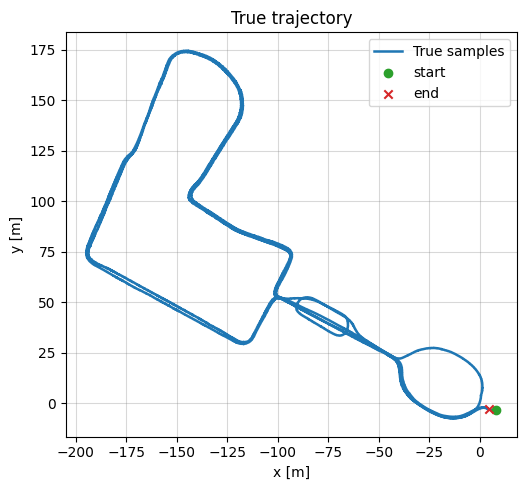

In [16]:
true_timestamps, true_trajectory = new_college_dataset.data.import_true_trajectory(DATASET_ROOT / "ground_truth/registered_poses.csv")
true_trajectory = transform.transform_se3s(true_trajectory, np.linalg.inv(T_B_L_WORLD))         # B in world to B in lidar world
true_trajectory = transform.transform_se3s(true_trajectory, T_B_L_WORLD, left=False)         # B in lidar world to lidar in lidar world
# lidar_poses = transform.transform_se3s(lidar_poses, np.linalg.inv(T_B_L_WORLD), left=False)     # Lidar in lidar world to B in lidar world
# true_trajectory = transform.transform_se3s(true_trajectory, np.linalg.inv(T_B_L_WORLD), left=False)
true_poses = true_trajectory
pose_timestamps = true_timestamps
fig, axis = calib_observability.plotting.plot_trajectory_2d(
    true_trajectory,
    title="True trajectory",
    label="True samples",)

In [17]:
# calib_observability.plotting.plot_trajectory_2d(lidar_poses)

trajectory /home/camel/Skoltech/phd_proposal/outputs/factor_graph_simulated_trajectory/dataset_trajectory_overview.png


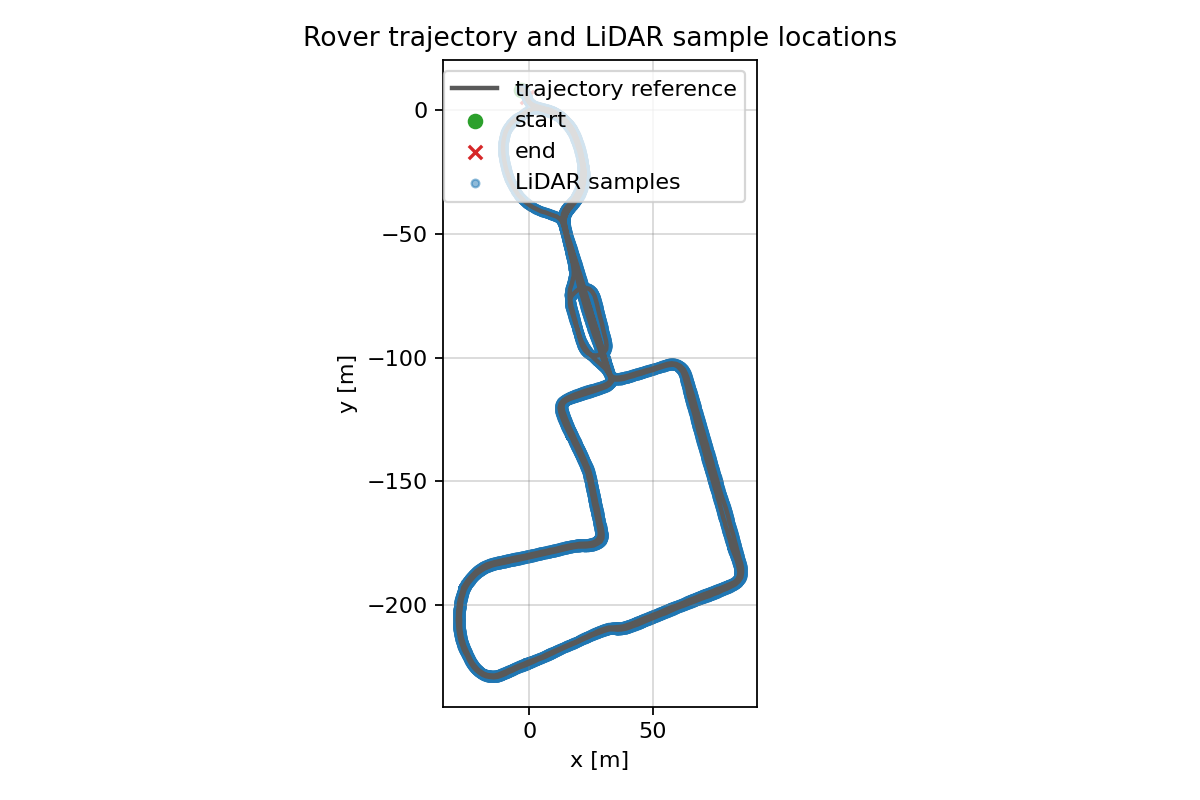

sensors /home/camel/Skoltech/phd_proposal/outputs/factor_graph_simulated_trajectory/dataset_sensor_overview.png


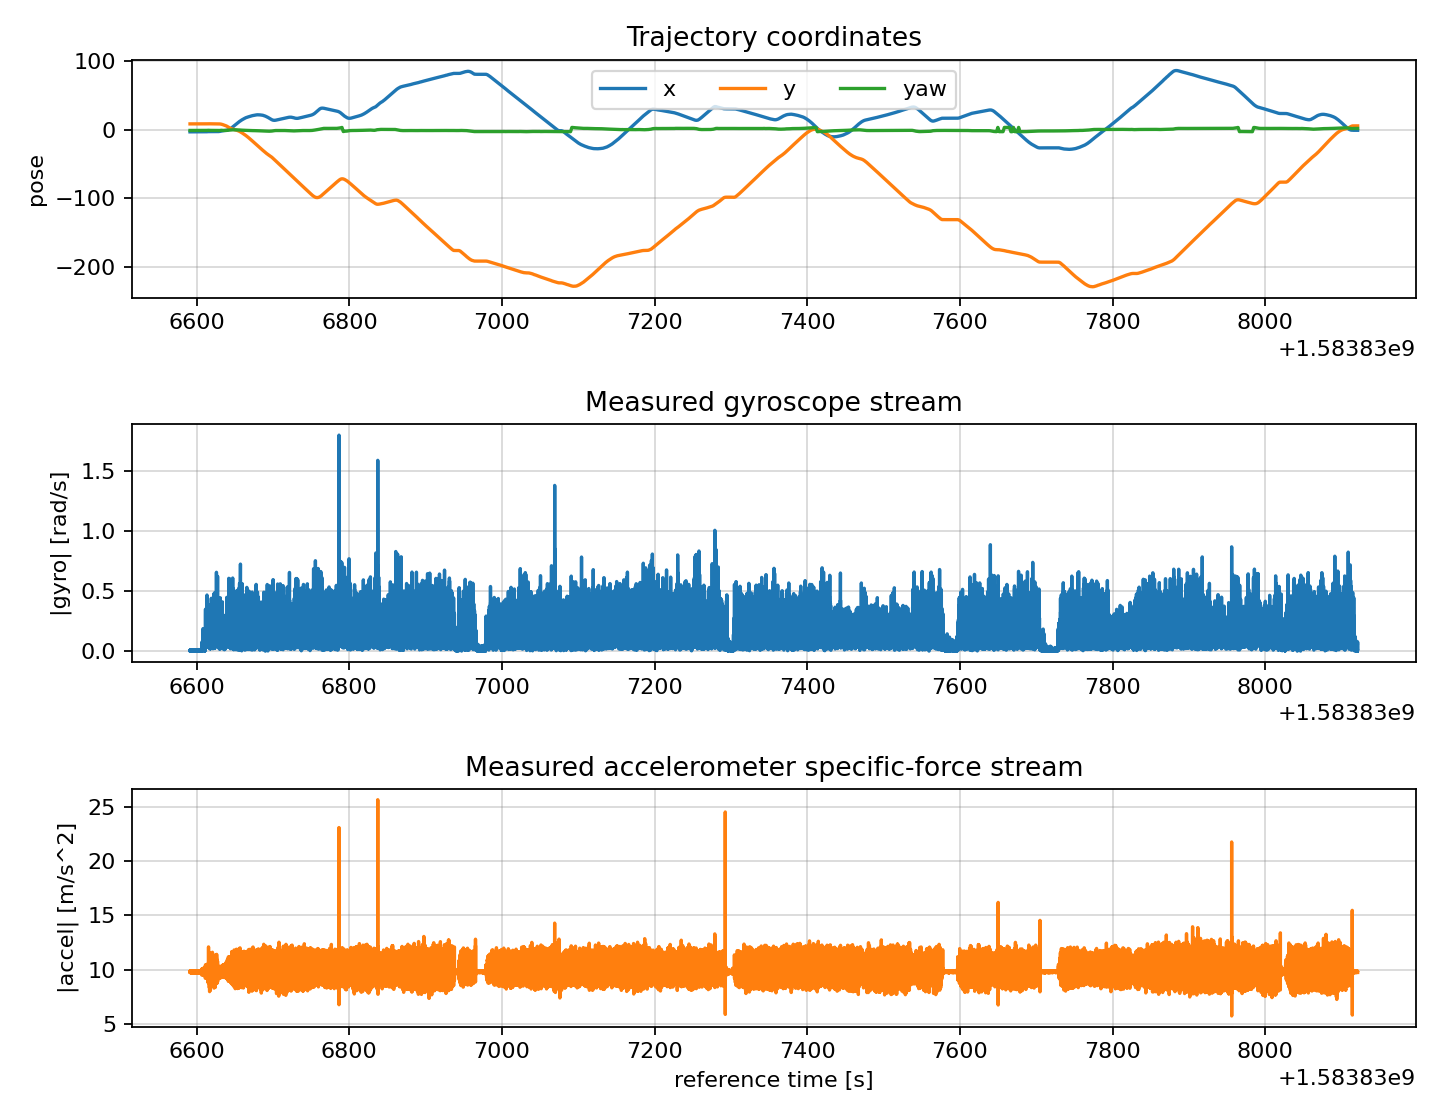

In [18]:
overview_paths = plot_rover_dataset_overview(dataset, OUT, trajectory_samples=900)
for name, path in overview_paths.items():
    print(name, path)
    display(Image(filename=str(path)))


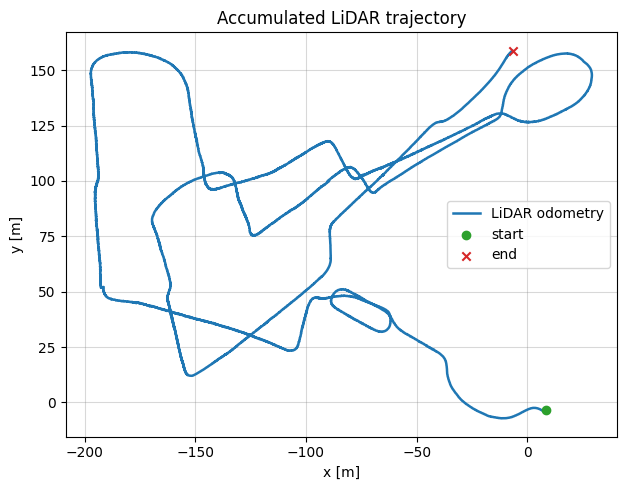

In [19]:

# accumulated_lidar_poses = np.empty((lidar_timestamps.size, 4, 4), dtype=float)
# accumulated_lidar_poses[0] = true_poses[5]
# for measurement_index, relative_pose in enumerate(dataset.lidar.measurements):
#     accumulated_lidar_poses[measurement_index + 1] = accumulated_lidar_poses[measurement_index] @ relative_pose
init_lidar_poses = data_processing._initialize_trajectory_poses(
    pose_timestamps=pose_timestamps[5:-5],
    states=[true_poses[5]],
    first_pose=true_poses[5],
    imu_timestamps=imu_timestamps,
    angular_velocity_imu=gyrs,
    T_B_I_initial=T_B_I_initial,
    bias_initial=GYRO_BIAS_INITIAL,
    tau_I_initial=TAU_I_INITIAL,
    lidar_timestamps=lidar_timestamps,
    lidar_odometry_poses=lidar_poses,        # lidar_poses, dataset.lidar.measurements
    T_B_L_initial=T_B_L_INITIAL,
    tau_L_initial=TAU_L_INITIAL,
)

fig, axis = calib_observability.plotting.plot_trajectory_2d(
    init_lidar_poses,
    title="Accumulated LiDAR trajectory",
    label="LiDAR odometry",)

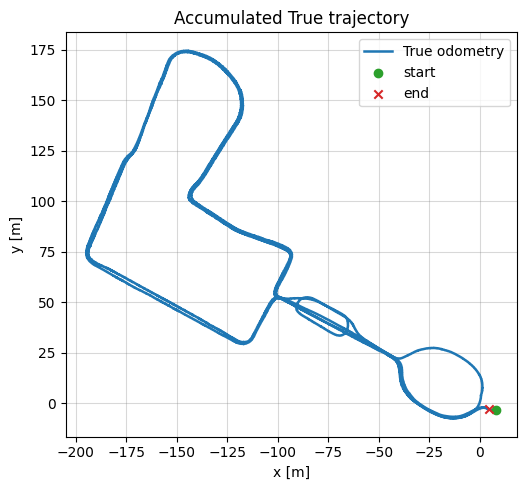

In [20]:


init_true_poses = data_processing._initialize_trajectory_poses(
    pose_timestamps=pose_timestamps[5:-5],
    states=[true_poses[5]],
    first_pose=true_poses[5],
    imu_timestamps=pose_timestamps[:-1],
    angular_velocity_imu=transform.se3_to_angvels(true_poses, pose_timestamps),
    T_B_I_initial=np.eye(4),
    bias_initial=GYRO_BIAS_INITIAL,
    tau_I_initial=TAU_I_INITIAL,
    lidar_timestamps=pose_timestamps,
    lidar_odometry_poses=true_poses,        # lidar_poses, dataset.lidar.measurements
    T_B_L_initial=T_B_L_INITIAL,
    tau_L_initial=TAU_L_INITIAL,
    use_imu_gyr=False
)

fig, axis = calib_observability.plotting.plot_trajectory_2d(
    init_true_poses,
    title="Accumulated True trajectory",
    label="True odometry",)

In [21]:
# R_B_I_EXPERIMENTAL = utils.scipy_rotation(gyrs[::10], transform.se3_to_angvels(lidar_poses, lidar_timestamps))
# T_B_I_EXPERIMENTAL = T_B_I_INITIAL.copy()
# T_B_I_EXPERIMENTAL[:3, :3] = R_B_I_EXPERIMENTAL
# print(T_B_I_EXPERIMENTAL)
# print(T_B_I_INITIAL)
# plot(gyrs)
# plot((R_B_I_EXPERIMENTAL.T @ transform.se3_to_angvels(lidar_poses, lidar_timestamps).T).T)

In [22]:
# plt.plot(transform.se3_to_poses(lidar_poses))

In [23]:
# plot(accs)
# plot(np.array([true_poses[i, :3, :3] @ T_B_I_INITIAL[:3, :3] @ accs[i*10] for i in range(int(len(accs)/10))]))

## 4. Run Rolling Factor Graph

This cell is only the algorithm execution. The call uses `FactorGraphCalibration.generate_filter_iterative` from `src/factor_graph_calibration.py`.

In [39]:
factor_graph = FactorGraphCalibration(
    imu_samples_per_factor=None,                    # IMU_SAMPLES_PER_FACTOR
    lidar_samples_per_factor=None,                  # LIDAR_SAMPLES_PER_FACTOR
    T_B_I_anchor=False,
    T_B_L_anchor=True,
    bias_anchor=False,
    tau_I_anchor=False,
    tau_L_anchor=True,
    # anchor_all_poses = True,
    anchor_first_pose=True,
    anchor_first_pose_each_window=True,
    anchor_last_pose=False,
    method=FACTOR_GRAPH_METHOD,
    imu_time_offset_margin=2.5,
    lidar_time_offset_margin=2.5,
    tau_I_regularization_information=10,
    T_B_I_regularization_information=np.diag([1.0, 1.0, 1.0, 1e6, 1e6, 1e6,]),
    bias_regularization_information=1,
    solver_verbose=False,
    gyro_information= 1e0,
    accel_information = 1e-3,
    lidar_information = 1e-2*(np.diag(1/lidar_noise**2)),
    scheduler=[(1e-5, 100), (1e-5, 100), (1e-9, 100)],
    gravity_world = (0, 0, 9.81),
    include_gyro_factors=True,
    include_accel_factors=True,
    include_lidar_factors=True,
    accel_norm_tolerance=0.75,
    accel_gyro_threshold=0.35,
)

# filter_graph.add_tau_regularization_factor(filter_graph.node_tau_I, target=0, information=10000000)

results = factor_graph.generate_filter_iterative(
    window_size=WINDOW_SIZE*10,
    step_size=WINDOW_SIZE*10/2,
    pose_timestamps=pose_timestamps[5:-5],
    states=init_lidar_poses,               # true_poses, [init_lidar_poses[0]]
    imu_timestamps=imu_timestamps,
    angular_velocity_imu=gyrs,
    specific_force_imu=accs,
    lidar_timestamps=lidar_timestamps,
    lidar_odometry_poses=lidar_poses,
    T_B_I_initial=dataset.T_B_I_true,        # dataset.T_B_I_true, T_B_I_EXPERIMENTAL
    T_B_L_initial=T_B_L_INITIAL,             # T_B_L_INITIAL
    bias_initial=np.zeros(3),
    tau_I_initial=2.0,
    tau_L_initial=0.0,
    verbose=0,
)

estimated_timestamps, estimated_poses = factor_graph.rolling_trajectory

print(f"solved windows: {len(results)}")
print(f"stitched estimated poses: {estimated_poses.shape}")
if results:
    print(f"first chi2: {results[0].chi2_before:.3e} -> {results[0].chi2_after:.3e}")
    print(f"last chi2:  {results[-1].chi2_before:.3e} -> {results[-1].chi2_after:.3e}")
    print(f"last tau_I estimate error: {results[-1].tau_I - dataset.tau_I_true}")
    print(f"last bias estimate error: {results[-1].bias_g - dataset.gyro_bias_true}")
    print(f"last T_B_I estimate error: {utils.calculate_se3_rotation_distances(results[-1].T_B_I, dataset.T_B_I_true)}, {utils.calculate_se3_translation_distances(results[-1].T_B_I, dataset.T_B_I_true)}")
    print(f"last T_B_L estimate error: {utils.calculate_se3_distances(results[-1].T_B_L, dataset.T_B_L_true)}")

solved windows: 60
stitched estimated poses: (15248, 4, 4)
first chi2: 2.030e+01 -> 7.221e-01
last chi2:  1.282e-01 -> 1.096e-01
last tau_I estimate error: 0.07064069029219167
last bias estimate error: [-0.00247892  0.00535329  0.00128099]
last T_B_I estimate error: [0.07174587], [0.00614259]
last T_B_L estimate error: [0.]


In [40]:
mrob.SO3(results[-1].T_B_I[:3, :3] @ np.linalg.inv(dataset.T_B_I_true[:3, :3])).Ln()
results[-1].T_B_I[:3, :3] @ np.linalg.inv(dataset.T_B_I_true[:3, :3])

array([[ 9.99071230e-01, -4.30439874e-02, -1.97289363e-03],
       [ 4.30862991e-02,  9.97427641e-01,  5.72858792e-02],
       [-4.97994028e-04, -5.73176785e-02,  9.98355866e-01]])

## 5. Visualize True, Initial, And Calculated Trajectories

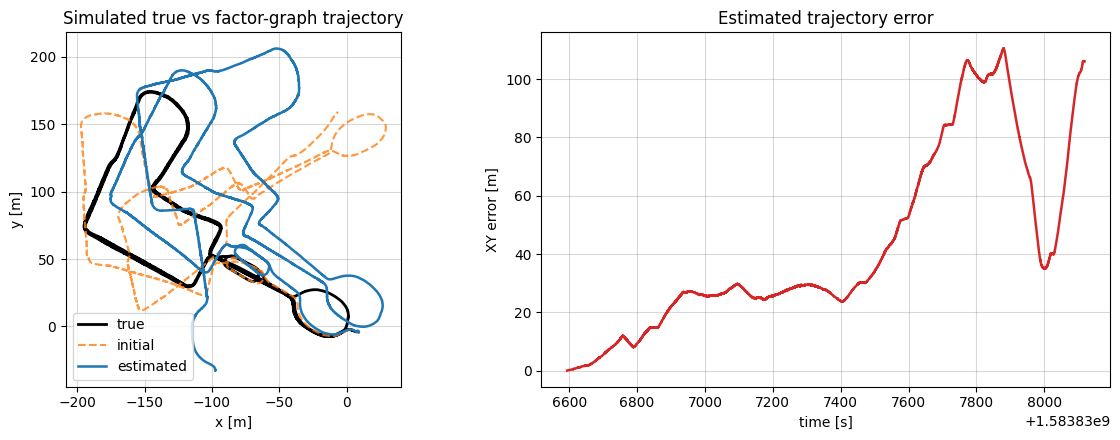

In [41]:
fig, axes = plot_trajectory_comparison(
    true_poses[5:-5],          # true_poses
    estimated_poses,
    true_timestamps=pose_timestamps[5:-5],
    estimated_timestamps=estimated_timestamps,
    initial_poses=init_lidar_poses,
    title="Simulated true vs factor-graph trajectory",
)
if SAVE_FIGURES:
    fig.savefig(OUT / "trajectory_comparison.png", dpi=160)
plt.show()
plt.close(fig)

In [27]:
# i_shift = np.argmax(pose_timestamps-estimated_timestamps[0]>0)
# true_poses_cut = true_poses[i_shift:i_shift+len(estimated_timestamps)]
# print(np.mean(utils.calculate_se3_distances(estimated_poses, true_poses_cut)))
# plt.plot(utils.calculate_se3_distances(estimated_poses, true_poses_cut))


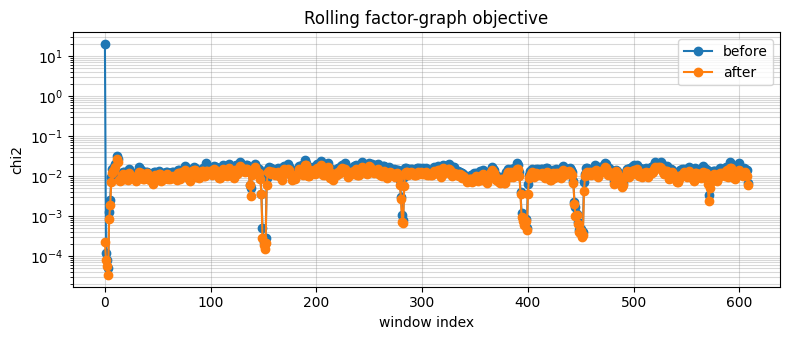

In [28]:
fig, axis = plot_calibration_window_chi2(results)
if SAVE_FIGURES:
    fig.savefig(OUT / "rolling_window_chi2.png", dpi=160)
plt.show()
plt.close(fig)

## 6. Window Summary Table

In [29]:
summary_rows = []
for result in results:
    summary_rows.append({
        "window": result.window_index,
        "start": result.window_start,
        "end": result.window_end,
        "poses": result.pose_timestamps.size,
        "chi2_before": result.chi2_before,
        "chi2_after": result.chi2_after,
        "bias estimate error": result.bias_g - dataset.gyro_bias_true,
        "T_B_I estimate error": f"{utils.calculate_se3_rotation_distances(result.T_B_I, dataset.T_B_I_true)}, {utils.calculate_se3_translation_distances(result.T_B_I, dataset.T_B_I_true)}",
        "T_B_L estimate error": utils.calculate_se3_distances(result.T_B_L, dataset.T_B_L_true),
        # "gyro_factors": result.factor_counts.get("gyro", 0),
        # "accel_factors": result.factor_counts.get("accel", 0),
        # "lidar_factors": result.factor_counts.get("lidar", 0),
        "tau_I": result.tau_I,
        "tau_L": result.tau_L,
    })

try:
    import pandas as pd
    display(pd.DataFrame(summary_rows))
except ImportError:
    summary_rows[:5]

,window,start,end,poses,chi2_before,chi2_after,bias estimate error,T_B_I estimate error,T_B_L estimate error,tau_I,tau_L
0,0,1.583837e+09,1.583837e+09,50,20.002639,0.000226,"[-0.001764684439735786, 0.0008953617347255803,...","[0.00982564], [0.0008345]",[0.0],-0.000808,0.0
1,1,1.583837e+09,1.583837e+09,50,0.000119,0.000080,"[-0.0006948932674604228, 0.0008263865245516338...","[0.01038738], [0.00088154]",[0.0],0.000087,0.0
2,2,1.583837e+09,1.583837e+09,50,0.000082,0.000057,"[-0.0007505378752339942, 0.0008285359446151178...","[0.01075741], [0.00091488]",[0.0],0.000490,0.0
3,3,1.583837e+09,1.583837e+09,50,0.000051,0.000033,"[-0.0006831561808207137, 0.0008555713502179699...","[0.01091428], [0.00093027]",[0.0],0.000266,0.0
4,4,1.583837e+09,1.583837e+09,50,0.001256,0.000860,"[-0.0017297666384223902, 0.0009656054027014575...","[0.0110422], [0.0009418]",[0.0],-0.000903,0.0
...,...,...,...,...,...,...,...,...,...,...,...
604,604,1.583838e+09,1.583838e+09,50,0.015614,0.012186,"[-0.001494974279039598, -0.000635681702295243,...","[0.17065622], [0.01305204]",[0.0],0.013748,0.0
605,605,1.583838e+09,1.583838e+09,50,0.015162,0.012426,"[-0.0018709279849620426, -0.001342733679358974...","[0.17056718], [0.01298162]",[0.0],0.012318,0.0
606,606,1.583838e+09,1.583838e+09,50,0.013712,0.010635,"[0.0008985080326709497, 0.0036011838880315645,...","[0.16930437], [0.012835]",[0.0],0.003360,0.0
607,607,1.583838e+09,1.583838e+09,50,0.014294,0.010243,"[0.0014657741785762401, 0.004072297356993459, ...","[0.16945636], [0.01271558]",[0.0],0.002058,0.0
